In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Normal/0117.jpeg
/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Normal/0101.jpeg
/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Normal/0108.jpeg
/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Normal/0110.jpeg
/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Normal/0119.jpeg
/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Normal/0115.jpeg
/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Normal/0116.jpeg
/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Normal/0105.jpeg
/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Normal/0106.jpeg
/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Normal/0121.jpeg
/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Normal/0111.jpeg
/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Normal/0103.jpeg
/kaggle/input/covid19-image-dataset/Covid19-dataset/test/Normal/0120.jpeg
/kaggle/input/covid19-image-dataset/Co

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.layers import *
from keras.models import Sequential
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
import warnings
warnings.filterwarnings('ignore')

2025-04-10 18:46:52.976842: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744310813.200244      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744310813.262758      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
train_path = '/kaggle/input/covid19-image-dataset/Covid19-dataset/train'
test_path = '/kaggle/input/covid19-image-dataset/Covid19-dataset/test'

In [4]:
img_classes = os.listdir(train_path)
print(img_classes)

['Normal', 'Viral Pneumonia', 'Covid']


In [5]:
len(img_classes)

3

In [6]:
def plot_frist_image_from_each_class(path):
    
    img_classes = os.listdir(path)
    plt.figure(figsize = (12,12))

    for i, category in enumerate(img_classes):
    
        image_path = path + '/' + category
        images_in_folder = os.listdir(image_path)
        
        first_img = images_in_folder[0]
        first_img_path = image_path + '/' + first_img
        
        
        img = image.load_img(first_img_path)
        img_array = image.img_to_array(img)/255
        
        
        plt.subplot(1,len(img_classes),i +1)
        plt.imshow(img_array)
        plt.title(category)
        plt.axis('off')
    plt.show()

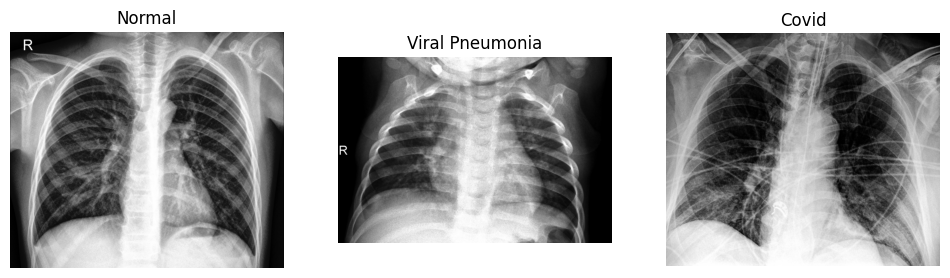

In [7]:
plot_frist_image_from_each_class(train_path)

In [8]:
# def add_padding(image):
#     return tf.image.resize_with_corp_or_pad( image, target_height = 250, target_width=250)

In [9]:
train_gen = ImageDataGenerator(
    # preprocessing_function = add_padding,
    rescale =1/255,
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    #fill_mode = 'nearst'
)

In [10]:
test_gen = ImageDataGenerator(rescale =1/255)

In [11]:
train_data = train_gen.flow_from_directory(train_path,
                                          target_size = (224,224),
                                          batch_size= 32,
                                          class_mode = 'categorical')

Found 251 images belonging to 3 classes.


In [12]:
test_data = test_gen.flow_from_directory(test_path,
                                          target_size = (224,224),
                                          batch_size= 1,
                                          class_mode = 'categorical')

Found 66 images belonging to 3 classes.


In [13]:
model = Sequential()

###conv-------------------------------
model.add(Conv2D(filters = 32, kernel_size = 3,padding = 'same',
                    activation = 'relu',input_shape = [224,224,3] ))

#add MaxPooling layer
model.add(MaxPooling2D(pool_size = (2,2)))

model.add(Conv2D(filters = 64, kernel_size = 3,padding = 'same',
                    activation = 'relu'))
model.add(MaxPooling2D())


model.add(Conv2D(filters = 128, kernel_size = 3, 
                    activation = 'relu'))
model.add(MaxPooling2D())

model.add(Flatten())


#### NN -------------------------------
model.add(Dense(128, activation = 'relu'))
model.add(Dense(128, activation = 'relu'))


model.add(Dense(3, activation = 'softmax'))

I0000 00:00:1744310827.358265      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 54, 54, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 27, 27, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 93312)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,944,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,054,211 (45.98 MB)

 Trainable params: 12,054,211 (45.98 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#cmpile Model
model.compile(optimizer = 'adam',
             loss = 'categorical_crossentropy',
            metrics = ['accuracy'] )

In [16]:
num_ep = 5

In [17]:
model_history = model.fit(train_data, epochs = num_ep, validation_data = test_data)

Epoch 1/5


I0000 00:00:1744310842.307547      78 service.cc:148] XLA service 0x7d89ac004860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744310842.308525      78 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1744310842.618780      78 cuda_dnn.cc:529] Loaded cuDNN version 90300


7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3340 - loss: 1.4990

I0000 00:00:1744310846.410691      78 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 708ms/step - accuracy: 0.3350 - loss: 1.4662 - val_accuracy: 0.6667 - val_loss: 1.0445
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.6340 - loss: 1.0165 - val_accuracy: 0.6212 - val_loss: 0.9220
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - accuracy: 0.6791 - loss: 0.7038 - val_accuracy: 0.6515 - val_loss: 0.8198
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - accuracy: 0.7177 - loss: 0.7221 - val_accuracy: 0.5606 - val_loss: 0.9129
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.7239 - loss: 0.7081 - val_accuracy: 0.5909 - val_loss: 0.7086


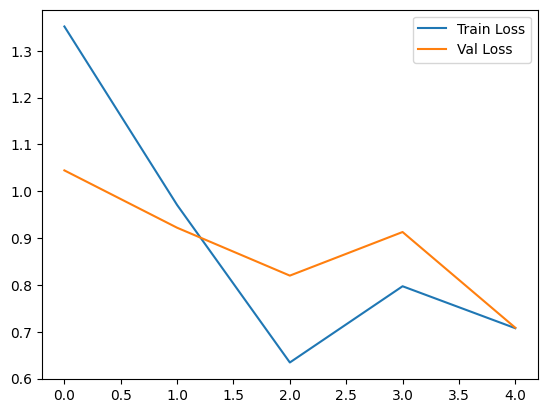

In [18]:
plt.plot(model_history.history['loss'], label = 'Train Loss')
plt.plot(model_history.history['val_loss'], label = 'Val Loss')
plt.legend()
plt.show()

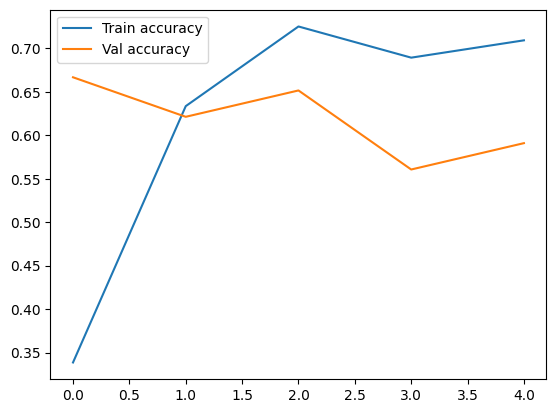

In [19]:
plt.plot(model_history.history['accuracy'], label = 'Train accuracy')
plt.plot(model_history.history['val_accuracy'], label = 'Val accuracy')
plt.legend()
plt.show()